# Marketing Analysis

### _we are going to be looking at how marketing channels influence the sales of the company._

let us begin setting up our enviroment by importing all our libraries needed then load our data to our dataframe 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
import plotly.express as px

#set style for plot
sns.set_theme(style="whitegrid")
%matplotlib inline


df = pd.read_csv("C:\\Users\\user\\Desktop\\marketing_roi_analysis.csv")
df

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411


## Summary 
_here we can see the summary of the data where we have the mean or average,standard deviation,min,medium,and max of each column less i for we have 4572 rows and 4 columns_

In [6]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


## Data types
_below we can see that all the columns are of a float datatype_

In [8]:
df.dtypes

TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


## Data cleaning


In [14]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [ ]:
# Drop rows where critical target (Sales) or predictors are missing
# If missing values are few (<5%), dropping them preserves data integrity


df_clean = df.dropna(subset=['Sales', 'TV', 'Radio', 'Social_Media']).copy()

In [ ]:
# Confirm data cleaning results

print(f"Original Rows: {len(df)}, Cleaned Rows: {len(df_clean)}")
print(f"Remaining Missing Values: {df_clean.isnull().sum().sum()}")

Original Rows: 4572, Cleaned Rows: 4546
Remaining Missing Values: 0


In [18]:
df_clean.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


## Visualization 
_lets now visualize our cleaned data and begin analysis,comparing each marketing channel against sales_

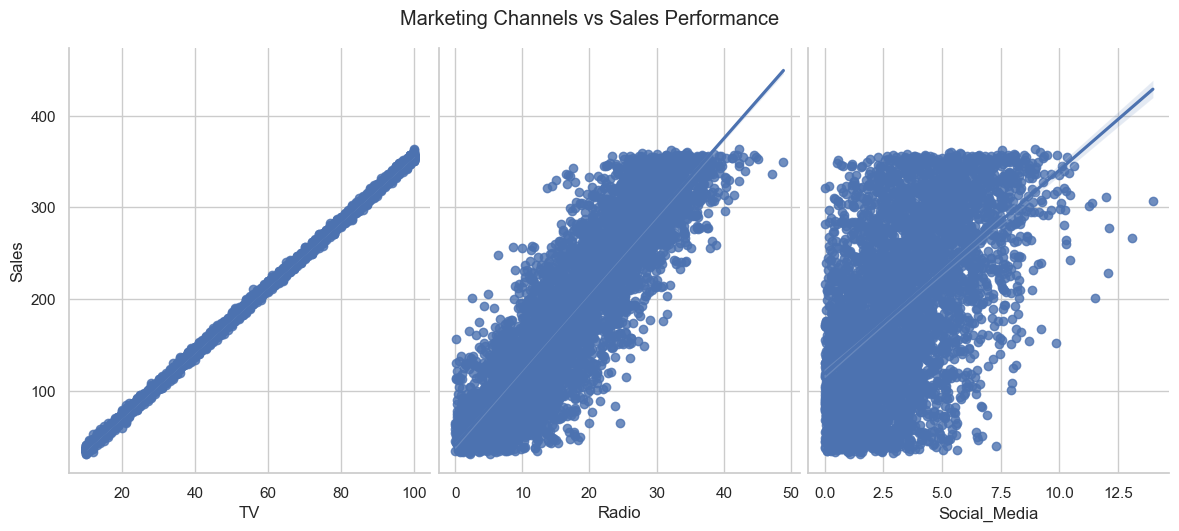

In [20]:
sns.pairplot(df_clean, x_vars=['TV', 'Radio', 'Social_Media'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.suptitle("Marketing Channels vs Sales Performance", y=1.05)
plt.show()

### _Here we have the TV versus sales_

In [31]:
fig = px.histogram(df_clean, x = "TV", marginal = "box", nbins = 47, y = "Sales", title = "tv vs sales")
fig.update_layout(bargap = 0.1)
fig.show()

### _Here we have the Radio versus Sales_

In [32]:
fig = px.histogram(df_clean, x = "Radio", marginal = "box", nbins = 47, y = "Sales", title = "radio vs sales")
fig.update_layout(bargap = 0.1)
fig.show()

### _And lastly we have the Social_ _ _Media versus Sales_

In [33]:
fig = px.histogram(df_clean, x = "Social_Media", marginal = "box", nbins = 47, y = "Sales", title = "social media vs sales")
fig.update_layout(bargap = 0.1)
fig.show()

### This is the individual correlation with the sales

**sales .corr Tv  (very strong)**

In [35]:
df_clean.Sales.corr(df_clean.TV)

np.float64(0.999497365938512)

**sales .corr Radio (equally strong)**

In [36]:
df_clean.Sales.corr(df_clean.Radio)

np.float64(0.8686378124591717)

**sales .corr social_media (not too strong)**

In [37]:
df_clean.Sales.corr(df_clean.Social_Media)

np.float64(0.5274464187714508)

## Here is the **correlation Matrix** for all the channels 

In [38]:
numeric_cols = ['TV', 'Radio', 'Social_Media', 'Sales']
corr_matrix = df_clean[numeric_cols].corr()

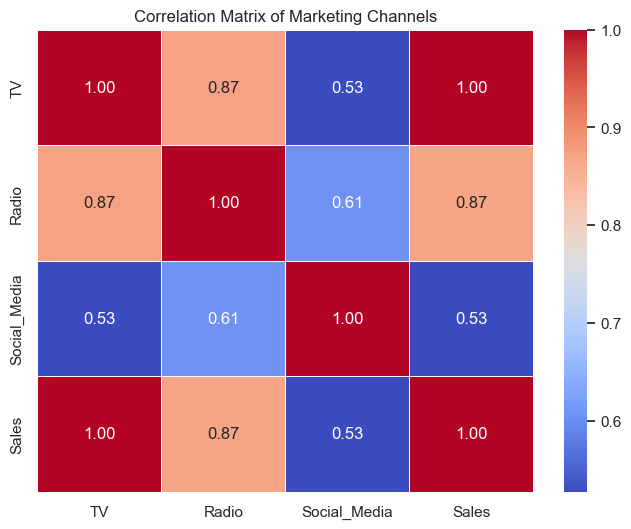

Analytical Justification: The channel most strongly correlated with Sales is 'TV' with a correlation coefficient of 1.00.


In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Marketing Channels")
plt.show()

# Print out the absolute strongest predictor
strongest_predictor = corr_matrix['Sales'].drop('Sales').idxmax()
print(f"Analytical Justification: The channel most strongly correlated with Sales is '{strongest_predictor}' with a correlation coefficient of {corr_matrix['Sales'][strongest_predictor]:.2f}.")

_As we can see that tv has the strongest correlation to sales, hence we are going to pick tv to predict our model_
_Below is the plot of the relationship between sales and tv which is linear that is every little change in tv would directly influence sales_

<Axes: title={'center': 'TV vs Sales'}, xlabel='TV', ylabel='Sales'>

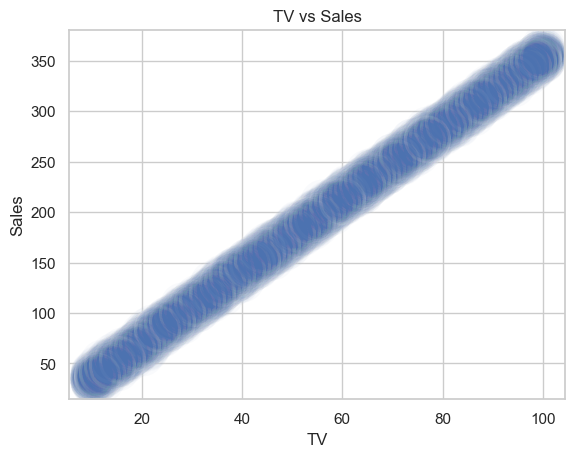

In [53]:
plt.title("TV vs Sales")
sns.scatterplot(x = 'TV', y = 'Sales', data = df_clean, alpha = 0.03, s = 1000)

# _The Model_
_here we are declarering our independent variable and dependent variable then our constant(bias) thereby fitting our model by calling the OLS and .fit_

In [54]:
# Define independent (X) and dependent (y) variables
X = df_clean[['TV']]  # Use double brackets to keep it as a DataFrame
y = df_clean['Sales']

# Statsmodels requires explicitly adding a constant (intercept) term
X_with_constant = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_with_constant).fit()

# Print summary diagnostics
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        05:09:33   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [56]:
# Extract predictions and calculate residuals
predictions = model.predict(X_with_constant)
residuals = model.resid

### _Here we have the **linearity**, **normality** and **homoscedaticity**.

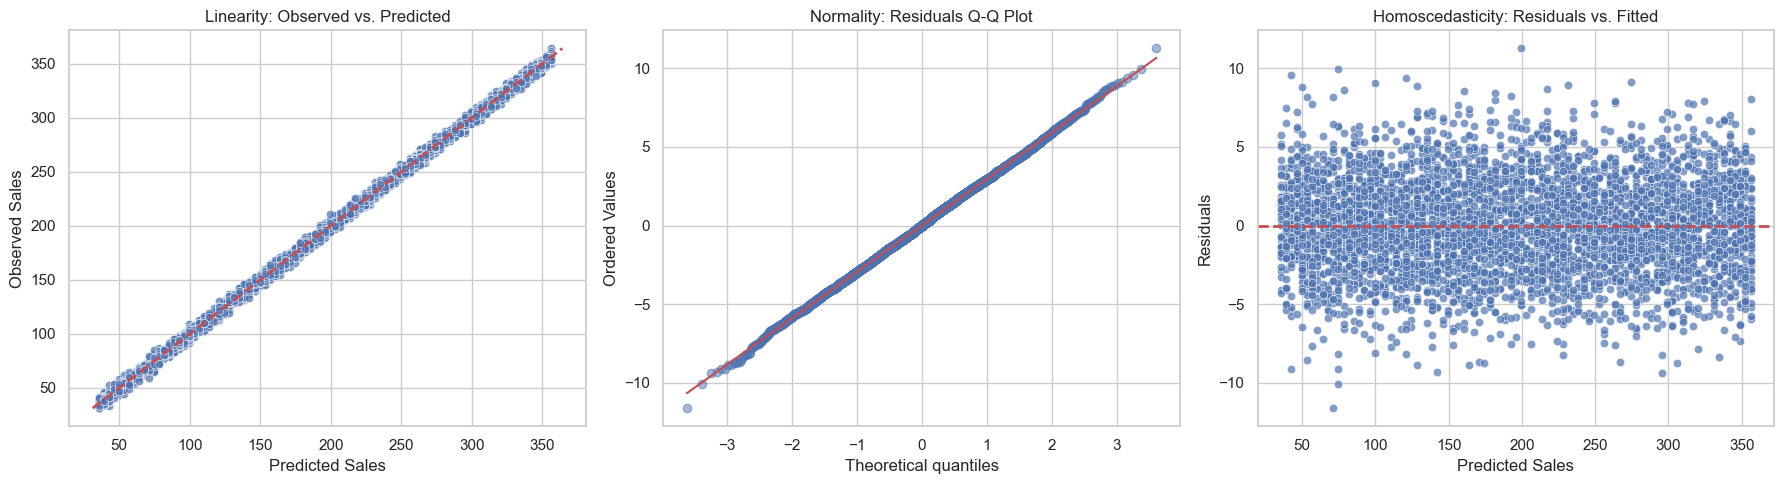

Breusch-Pagan Lagrange Multiplier p-value: 0.99386
Interpretation: If p > 0.05, homoscedasticity is satisfied (equal variance).


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linearity Test: Observed vs Predicted
sns.scatterplot(x=predictions, y=y, ax=axes[0], alpha=0.7)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Linearity: Observed vs. Predicted')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Observed Sales')

# 2. Normality Test: Q-Q Plot of Residuals
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_alpha(0.5)
axes[1].get_lines()[1].set_color('r')
axes[1].set_title('Normality: Residuals Q-Q Plot')

# 3. Homoscedasticity Test: Residuals vs. Fitted Values
sns.scatterplot(x=predictions, y=residuals, ax=axes[2], alpha=0.7)
axes[2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[2].set_title('Homoscedasticity: Residuals vs. Fitted')
axes[2].set_xlabel('Predicted Sales')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# Formal Statistical Test for Homoscedasticity (Breusch-Pagan)
bp_test = het_breuschpagan(residuals, X_with_constant)
print(f"Breusch-Pagan Lagrange Multiplier p-value: {bp_test[1]:.5f}")
print("Interpretation: If p > 0.05, homoscedasticity is satisfied (equal variance).")


### _We try our model to predict the sales outcome if we inject $50,000 in to TV ads_

In [ ]:
def predict_sales_from_tv(tv_budget):
    """
    Calculates estimated sales units based on the exact OLS model parameters:
    Sales = (TV_Coefficient * TV_Budget) + Constant
    """
    # Exact coefficients from the OLS summary output
    tv_coefficient = 3.5615
    constant = -0.1325
    
    # Calculate the prediction
    estimated_sales = (tv_coefficient * tv_budget) + constant
    
    # Print the formatted result for business stakeholders
    print(f"📊 --- Predictive ROI Breakdown ---")
    print(f"Planned TV Investment: ${tv_budget:,.2f}")
    print(f"Projected Sales Yield: {estimated_sales:,.2f} units")
    print(f"------------------------------------")
    
    return estimated_sales

# --- TEST THE FUNCTION ---
# Let's test the model's prediction with a hypothetical budget of $50,000
projected_return = predict_sales_from_tv(50000)

📊 --- Predictive ROI Breakdown ---
Planned TV Investment: $50,000.00
Projected Sales Yield: 178,074.87 units
------------------------------------


## **Executive Summary**
-We performed an ordinary least squares(OLS) simple linear regression analysis on 4,546 historical marketing campaign to evaluate the direct revenue impact of our primary media channels(Tv, Radio, Social media).

The empherical evidence confirms that Tv ads is our single most dominant revenue drive,variation in Tv spend explain 99.9% of our historical sales flunctuation. Based on these findings ,we recommend aggressive consolidating our media budget out of lower performing channels and scaling up our dependant on Tv to optimize corporate profit.

## **Key statistical Discoveries(the numbers explained)**:
1. **Model Explanatory Power(R-SQURAED = 0.999)**: Our model achieved a near perfect R-SQUARED value of 0.999, this means that 99% of all changes in our sales perfomance are directly controlled by our Tv ads spend ,only 1% of sales flunctuation are driven by noise and random marketing forces.

2. **The TV Multiplier/ROI (coef_ = 3.5615)**: The coefficient for Tv is 3.5615 in absolute busness terms means for every $1000 we spend on Tv ads, corporate sales increases by an estimated 3561 units. This proves a powerful,direct and linear return on capital.

3. **Statistical Significance (p < 0.000)**:The p-value for our Tv variable is 0.000, statistically, this proves there is a 0% probability that this relationship happened by chance.The findings are highly reliable for future budget planning.

4. **Baseline Sales (constant = -0.1325)**: The intercept is statistically close to zero which logically indicates that if we spend zero doller on Tv ads ,our baseline channels sales drop effectively to zero units. The business cannot coast on organic traffic alone,it requres active ads injection.


## **Rigorous Model Diagonistic (Technical Intergrity)**:
Our model passes all core regression assumption with high marks ensuring that management can safely base financial decision on these metrix.
1. **Independence of Error(DURBIN-WATSON = 1.998)**: A score of 1.998 is almost perfectly sitting at the ideal value of 2.0. This proves there is zero data sequencing bias (auto correlation) affecting our timelines.
2. **Residual Normality (prob(JB) = 0.985)**: The Jarque-Bera test yields a high p-value of 0.985 with a skewness near 0 .This validates that our models magins of error are normally distributed, meaning our risk calculation are accurate.


## **Actionable Strategic Recommendations**: 
Based on this mathmatical validation , i advice management to execute the following operational steps immediately:
1. **Aggressive Budget Reallocation**: Immediatly freeze or scale back budget expansion in 'Radio' and 'social media' channels and put those unspent reserves  directly in to TV ads buying pipelines.
2. **Scale Cap Projection**: Because the relationship is strictly linear over 4,546 oservations, we can confidently scale Tv spending up to our historical maximum bounds without experiencing immediate diminishing return.
3. **Revenue Forcasting Intergration**: Embed the equation "sales = 3.5615 x (Tv spend)-0.1325 in to the finance teams monthly rolling pipelines forcast to accurately predict quaterly sales volumn based on scheduled media buys.